In [1]:
!pip install seaborn


In [2]:
import shutil

# Remove hidden checkpoint folders
shutil.rmtree("./train/.ipynb_checkpoints", ignore_errors=True)
shutil.rmtree("./test/.ipynb_checkpoints", ignore_errors=True)

print("Hidden folders removed!")

Hidden folders removed!


In [3]:
import os

print(os.listdir("./train"))
print(os.listdir("./test"))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
class Config:
    
    # Dataset paths
    TRAIN_DATA_PATH = './train'
    TEST_DATA_PATH = './test'
    
    # Model parameters
    MODEL_NAME = 'resnet18'
    NUM_CLASSES = 7
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 0.001
    PATIENCE = 5

    BEST_MODEL_PATH = './checkpoints/best_model.pth'

    FINAL_MODEL_PATH = './checkpoints/final_model.pth'
    
    # Emotion classes
    EMOTION_CLASSES = {
        0: 'Angry',
        1: 'Disgusted',
        2: 'Fearful',
        3: 'Happy',
        4: 'Neutral',
        5: 'Sad',
        6: 'Surprised'
    }

    # Checkpoints
    CHECKPOINT_DIR = './checkpoints'

    def __init__(self):
        os.makedirs(self.CHECKPOINT_DIR, exist_ok=True)

config = Config()

print("Configuration loaded!")
print("Training Path:", config.TRAIN_DATA_PATH)
print("Test Path:", config.TEST_DATA_PATH)
print("Model:", config.MODEL_NAME)
print("Epochs:", config.NUM_EPOCHS)

Configuration loaded!
Training Path: ./train
Test Path: ./test
Model: resnet18
Epochs: 10


In [6]:
# # # Image transforms
# # transform = transforms.Compose([
# #     transforms.Resize((224, 224)),
# #     transforms.ToTensor()
# # ])

# # Load datasets
# train_dataset = datasets.ImageFolder(
#     root=config.TRAIN_DATA_PATH,
#     transform=transform
# )

# test_dataset = datasets.ImageFolder(
#     root=config.TEST_DATA_PATH,
#     transform=transform
# )

# # # Create dataloaders
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=config.BATCH_SIZE,
#     shuffle=True
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=config.BATCH_SIZE,
#     shuffle=False
# )

# # # Print dataset info
# print("Train Classes:", train_dataset.classes)
# # print("Number of Training Images:", len(train_dataset))
# # print("Number of Test Images:", len(test_dataset))

In [7]:
# Define transforms for training and testing
train_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Data augmentation transforms defined!")

Data augmentation transforms defined!


In [8]:
# Load datasets using ImageFolder

train_dataset = datasets.ImageFolder(
    root=config.TRAIN_DATA_PATH,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=config.TEST_DATA_PATH,
    transform=test_transform
)

# Create dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

# Dataset information

print("\nDataset Summary:")
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

print("\nEmotion Classes:")
print(train_dataset.classes)


Dataset Summary:
Training samples: 12069
Testing samples: 6965

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
class EmotionDetectionModel(nn.Module):
    """
    Emotion Detection Model using Transfer Learning
    """

    def __init__(self, model_name='resnet18', num_classes=7, pretrained=True):
        super(EmotionDetectionModel, self).__init__()

        # Load pretrained ResNet18
        if model_name == 'resnet18':

            self.backbone = models.resnet18(pretrained=pretrained)

            num_features = self.backbone.fc.in_features

            # Replace final layer
            self.backbone.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, num_classes)
            )

        else:
            raise ValueError(f"{model_name} not supported")


    def forward(self, x):
        return self.backbone(x)


# Create model

model = EmotionDetectionModel(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    pretrained=True
).to(device)


# Count parameters

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Model: {config.MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nModel Loaded Successfully!")

Model: resnet18
Total parameters: 11,180,103
Trainable parameters: 11,180,103

Model Loaded Successfully!


In [10]:



# Loss function

criterion = nn.CrossEntropyLoss()


# Optimizer

optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=1e-4
)


# Learning rate scheduler

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

print("Optimizer, Loss function, and Scheduler initialized!")

Optimizer, Loss function, and Scheduler initialized!


In [11]:
from torch.utils.data import random_split

# Split training dataset into train + validation

train_size = int(0.8 * len(train_dataset))

val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# Create train loader

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True
)

# Create validation loader

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 9655
Validation samples: 2414


In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        pbar.set_postfix({
            'loss': running_loss / (pbar.n + 1),
            'acc': 100 * correct / total
        })

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        pbar = tqdm(val_loader, desc='Validating')

        for images, labels in pbar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': running_loss / (pbar.n + 1),
                'acc': 100 * correct / total
            })

    epoch_loss = running_loss / len(val_loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


print("Training and validation functions defined!")

Training and validation functions defined!


In [13]:
# Initialize history

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

patience_counter = 0


# Training loop

for epoch in range(config.NUM_EPOCHS):

    print(f"\n{'='*60}")

    print(f"Epoch [{epoch+1}/{config.NUM_EPOCHS}]")

    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    history['train_loss'].append(train_loss)

    history['train_acc'].append(train_acc)

    # Validate
    val_loss, val_acc, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history['val_loss'].append(val_loss)

    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Update scheduler
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        patience_counter = 0

        torch.save(
            model.state_dict(),
            config.BEST_MODEL_PATH
        )

        print(f"✓ Best model saved! Val Acc: {val_acc:.2f}%")

    else:

        patience_counter += 1

        print(f"No improvement. Patience: {patience_counter}/{config.PATIENCE}")

    # Early stopping
    if patience_counter >= config.PATIENCE:

        print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")

        break


# Save final model

torch.save(
    model.state_dict(),
    config.FINAL_MODEL_PATH
)

print(f"\n✓ Training completed!")

print(f"Models saved to: {config.CHECKPOINT_DIR}")


Epoch [1/10]


Validating: 100%|█████████████████████████████████████████████████| 76/76 [00:21<00:00,  3.56it/s, loss=1.47, acc=45.2]



Train Loss: 1.6081 | Train Acc: 39.39%
Val Loss: 1.4667 | Val Acc: 45.19%
✓ Best model saved! Val Acc: 45.19%

Epoch [2/10]


Validating: 100%|██████████████████████████████████████████████████| 76/76 [00:20<00:00,  3.67it/s, loss=1.3, acc=50.8]



Train Loss: 1.3889 | Train Acc: 46.93%
Val Loss: 1.3000 | Val Acc: 50.79%
✓ Best model saved! Val Acc: 50.79%

Epoch [3/10]


...


Train Loss: 1.1003 | Train Acc: 58.92%
Val Loss: 1.1674 | Val Acc: 54.97%
No improvement. Patience: 2/5

Epoch [9/10]


Validating: 100%|█████████████████████████████████████████████████| 76/76 [00:19<00:00,  3.89it/s, loss=1.18, acc=56.8]



Train Loss: 1.0712 | Train Acc: 60.01%
Val Loss: 1.1798 | Val Acc: 56.75%
✓ Best model saved! Val Acc: 56.75%

Epoch [10/10]


Validating: 100%|█████████████████████████████████████████████████| 76/76 [00:18<00:00,  4.00it/s, loss=1.12, acc=59.2]



Train Loss: 1.0462 | Train Acc: 60.61%
Val Loss: 1.1163 | Val Acc: 59.24%
✓ Best model saved! Val Acc: 59.24%

✓ Training completed!
Models saved to: ./checkpoints


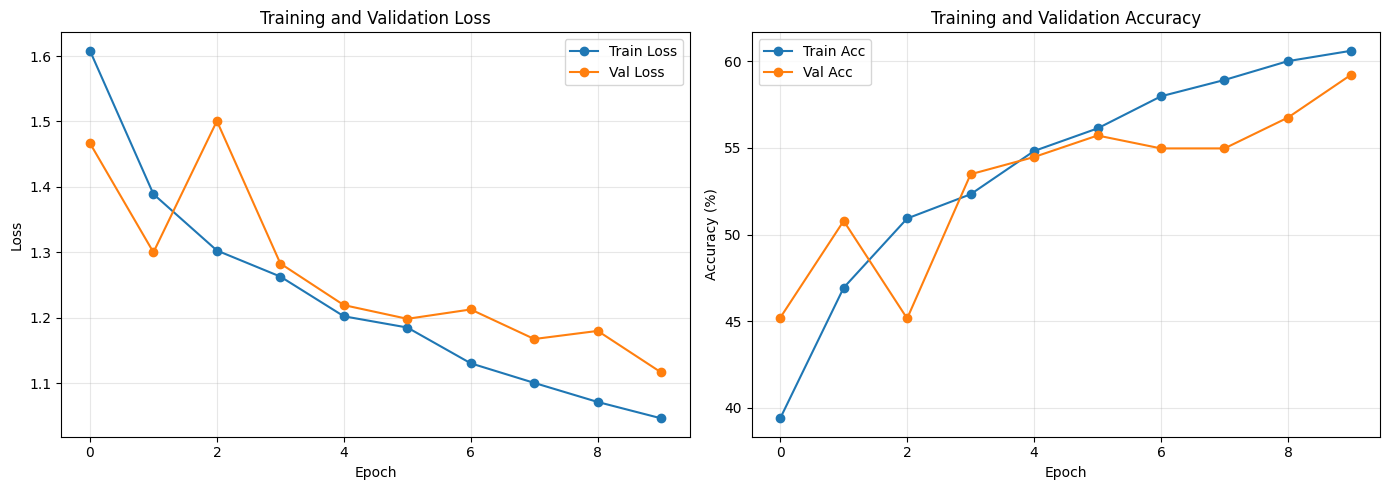

Training history plot saved!


In [14]:
# Create figure with subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(
    history['train_loss'],
    label='Train Loss',
    marker='o'
)

axes[0].plot(
    history['val_loss'],
    label='Val Loss',
    marker='o'
)

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Loss')

axes[0].set_title('Training and Validation Loss')

axes[0].legend()

axes[0].grid(True, alpha=0.3)


# Accuracy plot
axes[1].plot(
    history['train_acc'],
    label='Train Acc',
    marker='o'
)

axes[1].plot(
    history['val_acc'],
    label='Val Acc',
    marker='o'
)

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Accuracy (%)')

axes[1].set_title('Training and Validation Accuracy')

axes[1].legend()

axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(config.CHECKPOINT_DIR, 'training_history.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Training history plot saved!")

In [15]:
# Load best model

model.load_state_dict(
    torch.load(config.BEST_MODEL_PATH)
)

# Evaluation mode
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    pbar = tqdm(test_loader, desc='Testing')

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

        all_probs.extend(probs.cpu().numpy())


all_preds = np.array(all_preds)

all_labels = np.array(all_labels)

all_probs = np.array(all_probs)


# Metrics

test_acc = accuracy_score(all_labels, all_preds)

test_f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print(f"\n{'='*60}")

print("Test Results")

print(f"{'='*60}")

print(f"Test Accuracy: {test_acc*100:.2f}%")

print(f"Test F1-Score (weighted): {test_f1:.4f}")

print("\nDetailed Classification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=list(config.EMOTION_CLASSES.values())
    )
)

Testing: 100%|███████████████████████████████████████████████████████████████████████| 218/218 [00:22<00:00,  9.79it/s]


Test Results
Test Accuracy: 60.04%
Test F1-Score (weighted): 0.5936

Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.56      0.49      0.53       958
   Disgusted       0.53      0.35      0.42       111
     Fearful       0.49      0.33      0.40      1025
       Happy       0.78      0.82      0.80      1560
     Neutral       0.54      0.62      0.58      1233
         Sad       0.46      0.50      0.48      1247
   Surprised       0.70      0.79      0.74       831

    accuracy                           0.60      6965
   macro avg       0.58      0.56      0.56      6965
weighted avg       0.59      0.60      0.59      6965



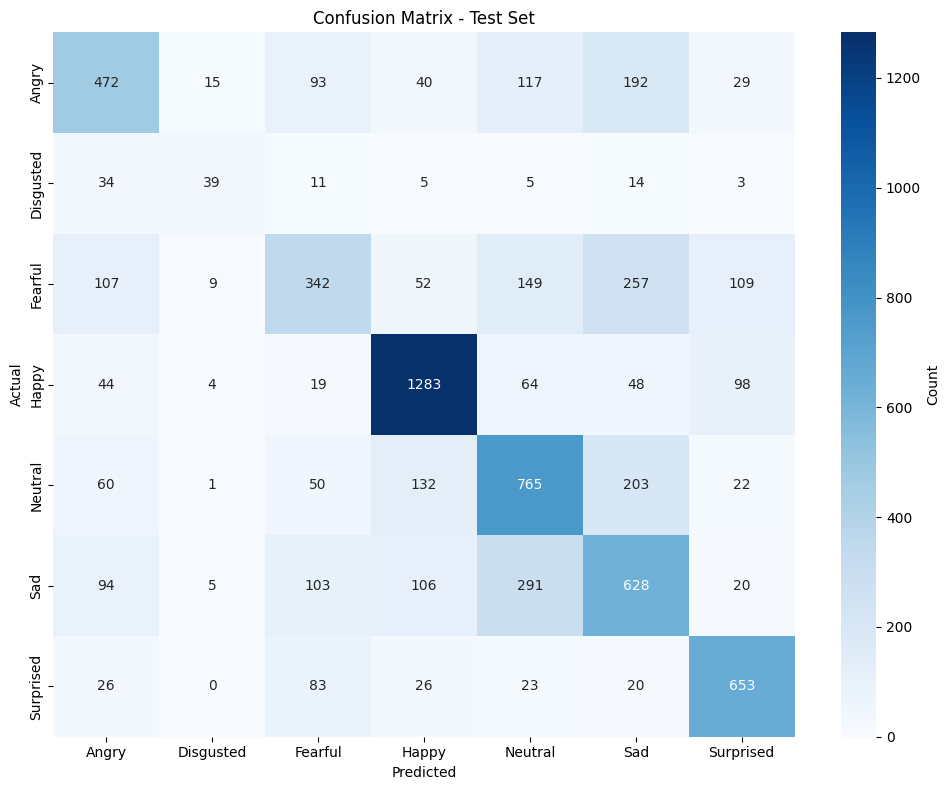

Confusion matrix saved!


In [16]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(config.EMOTION_CLASSES.values()),
            yticklabels=list(config.EMOTION_CLASSES.values()),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig(os.path.join(config.CHECKPOINT_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved!")

In [17]:
def predict_emotion(image_path, model, device, transform, emotion_classes):
    """
    Predict emotion for a single image.
    
    Args:
        image_path: Path to image file
        model: Trained model
        device: Device to use
        transform: Image transform
        emotion_classes: Dictionary of emotion classes
    
    Returns:
        emotion: Predicted emotion
        confidence: Confidence score
        all_probs: Probabilities for all classes
    """
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)
    
    emotion = emotion_classes[predicted.item()]
    confidence = confidence.item()
    all_probs = probs.cpu().numpy()[0]
    
    return emotion, confidence, all_probs


def visualize_prediction(image_path, emotion, confidence, all_probs, emotion_classes):
    """
    Visualize prediction with probabilities.
    """
    image = Image.open(image_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Image
    axes[0].imshow(image)
    axes[0].set_title(f'Prediction: {emotion}\nConfidence: {confidence:.2%}')
    axes[0].axis('off')
    
    # Probabilities
    emotions = list(emotion_classes.values())
    colors = ['green' if e == emotion else 'gray' for e in emotions]
    axes[1].barh(emotions, all_probs, color=colors, alpha=0.7)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Emotion Probabilities')
    axes[1].set_xlim([0, 1])
    
    # Add value labels
    for i, (emotion_name, prob) in enumerate(zip(emotions, all_probs)):
        axes[1].text(prob, i, f' {prob:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()

print("Prediction functions defined!")

Prediction functions defined!


Model loaded successfully!


Image: ./test/happy/PrivateTest_2911075.jpg
Predicted Emotion: Surprised
Confidence: 53.23%


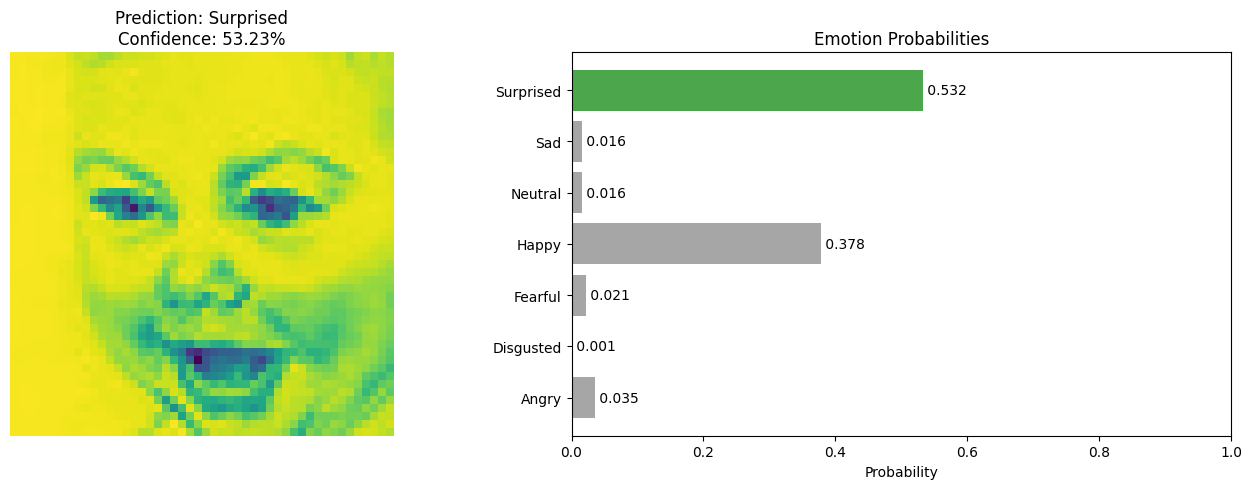


Image: ./test/angry/PrivateTest_1488292.jpg
Predicted Emotion: Angry
Confidence: 51.26%


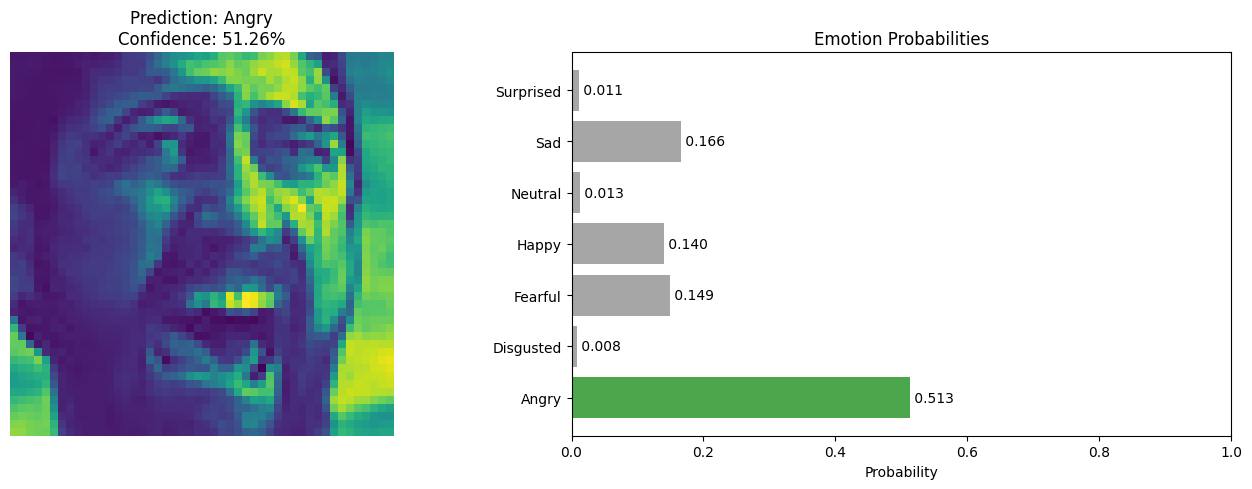


Image: ./test/surprise/PrivateTest_914251.jpg
Predicted Emotion: Surprised
Confidence: 77.04%


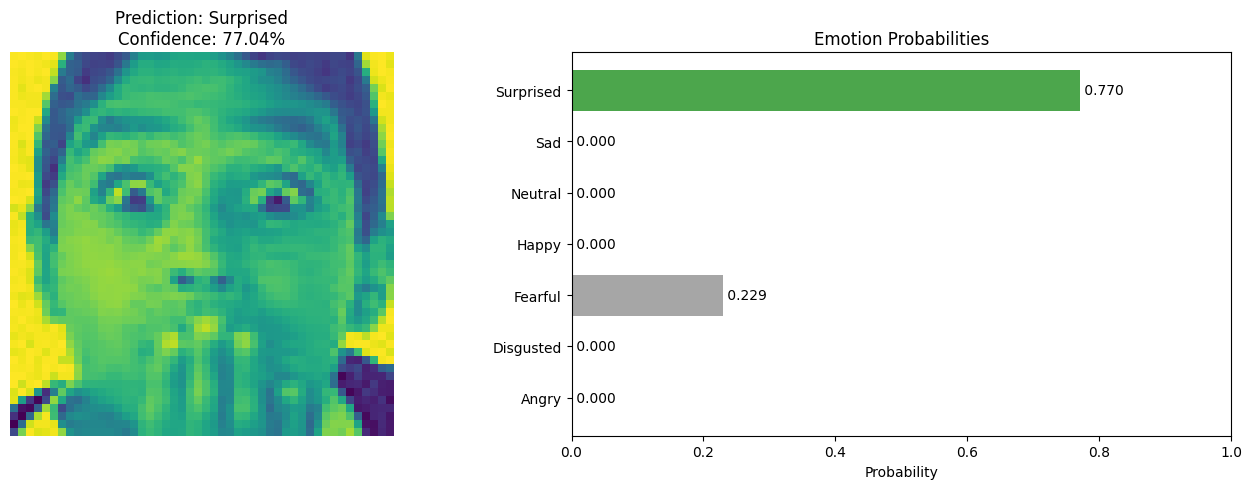

In [24]:
# Load best model

model.load_state_dict(
    torch.load(config.BEST_MODEL_PATH)
)

model.eval()

print("Model loaded successfully!\n")


# Example test image paths
# CHANGE THESE PATHS TO YOUR OWN IMAGES

# test_images = [

#     "./test/happy/PrivateTest_518212.jpg",

#     "./test/surprise/PrivateTest_914251.jpg",

#     "./test/happy/PrivateTest_95094.jpg"
# ]

# Example test images

test_images = [

    "./test/happy/PrivateTest_2911075.jpg",

    "./test/angry/PrivateTest_1488292.jpg",

    "./test/surprise/PrivateTest_914251.jpg"
]


# Predict emotions

for image_path in test_images:

    emotion, confidence, all_probs = predict_emotion(
        image_path,
        model,
        device,
        test_transform,
        config.EMOTION_CLASSES
    )

    print(f"\nImage: {image_path}")

    print(f"Predicted Emotion: {emotion}")

    print(f"Confidence: {confidence:.2%}")

    visualize_prediction(
        image_path,
        emotion,
        confidence,
        all_probs,
        config.EMOTION_CLASSES
    )


In [35]:
# def detect_emotion_in_video(video_path, model, device, transform, emotion_classes, 
#                             frame_interval=5, display=False):
#     """
#     Detect emotions in video frames.
    
#     Args:
#         video_path: Path to video file
#         model: Trained model
#         device: Device to use
#         transform: Image transform
#         emotion_classes: Dictionary of emotion classes
#         frame_interval: Process every nth frame
#         display: Whether to display frames with predictions
    
#     Returns:
#         results: List of predictions with timestamps
#     """
#     model.eval()
#     cap = cv2.VideoCapture(video_path)
    
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     frame_count = 0
#     results = []
    
#     emotion_counts = {emotion: 0 for emotion in emotion_classes.values()}
    
#     with torch.no_grad():
#         while cap.isOpened():
#             ret, frame = cap.read()
#             if not ret:
#                 break
            
#             if frame_count % frame_interval == 0:
#                 # Convert BGR to RGB
#                 rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#                 image = Image.fromarray(rgb_frame)
                
#                 # Predict
#                 image_tensor = transform(image).unsqueeze(0).to(device)
#                 outputs = model(image_tensor)
#                 probs = torch.softmax(outputs, dim=1)
#                 confidence, predicted = torch.max(probs, 1)
                
#                 emotion = emotion_classes[predicted.item()]
#                 conf = confidence.item()
#                 timestamp = frame_count / fps
                
#                 results.append({
#                     'frame': frame_count,
#                     'timestamp': timestamp,
#                     'emotion': emotion,
#                     'confidence': conf
#                 })
                
#                 emotion_counts[emotion] += 1
                
#                 if display:
#                     # Add text to frame
#                     cv2.putText(frame, f'{emotion} ({conf:.2f})', (10, 30),
#                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
#                     cv2.putText(frame, f'Frame: {frame_count}', (10, 70),
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
                    
#                     # Display frame (resize for notebook)
#                     display_frame = cv2.resize(frame, (640, 480))
#                     display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
#                     plt.imshow(display_frame_rgb)
#                     plt.axis('off')
#                     plt.show()
            
#             frame_count += 1
    
#     cap.release()
    
#     # Summary statistics
#     print(f"\nVideo Analysis Summary:")
#     print(f"Total frames processed: {len(results)}")
#     print(f"Emotion distribution:")
#     for emotion, count in emotion_counts.items():
#         if count > 0:
#             print(f"  {emotion}: {count}")
    
#     return results, emotion_counts

# print("Video emotion detection function defined!")



# Load OpenCV face detector
# Load OpenCV face detector

# Load face detector

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)


def detect_emotion_with_face_detection(

    video_path,
    model,
    device,
    transform,
    emotion_classes,
    output_path="fixed_output.mp4"

):

    model.eval()

    cap = cv2.VideoCapture(video_path)

    # Original video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fps = int(cap.get(cv2.CAP_PROP_FPS))


    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    out = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (width, height)
    )

    print("Processing video...\n")

    frame_count = 0


    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break


        # Keep ORIGINAL frame for saving
        output_frame = frame.copy()


        # Resize only for detection speed
        small_frame = cv2.resize(
            frame,
            (640, 480)
        )


        # Grayscale
        gray = cv2.cvtColor(
            small_frame,
            cv2.COLOR_BGR2GRAY
        )


        # Face detection
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=4,
            minSize=(30, 30)
        )


        # Scale coordinates back
        scale_x = width / 640

        scale_y = height / 480


        for (x, y, w, h) in faces:

            # Scale coordinates
            x1 = int(x * scale_x)

            y1 = int(y * scale_y)

            w1 = int(w * scale_x)

            h1 = int(h * scale_y)


            # Crop face from ORIGINAL frame
            # face = output_frame[y1:y1+h1, x1:x1+w1]

            face = frame[y1:y1+h1, x1:x1+w1]
            # Skip invalid crops
            if face.size == 0:
                continue


            # RGB conversion
            rgb_face = cv2.cvtColor(
                face,
                cv2.COLOR_BGR2RGB
            )

            # PIL image
            pil_image = Image.fromarray(rgb_face)

            # Transform
            image_tensor = transform(pil_image)

            image_tensor = image_tensor.unsqueeze(0).to(device)


            # Predict
            with torch.no_grad():

                outputs = model(image_tensor)

                probs = torch.softmax(outputs, dim=1)

                confidence, predicted = torch.max(probs, 1)


            emotion = emotion_classes[predicted.item()]

            confidence = confidence.item()


            # Draw rectangle
            cv2.rectangle(
                output_frame,
                (x1, y1),
                (x1+w1, y1+h1),
                (0, 255, 0),
                2
            )


            # Draw label
            cv2.putText(
                output_frame,
                f"{emotion} ({confidence:.2%})",
                (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )


        # Show frame
        cv2.imshow(
            "Emotion Detection",
            output_frame
        )


        # SAVE ORIGINAL-SIZED FRAME
        out.write(output_frame)


        frame_count += 1

        if frame_count % 30 == 0:

            print(f"Processed {frame_count} frames")


        # Quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


    cap.release()

    out.release()

    cv2.destroyAllWindows()

    print("\nVideo processing completed!")

    
    print(f"Saved video: {output_path}")
  

In [34]:
# Run video emotion detection

results, emotion_counts = detect_emotion_in_video(

    video_path="sample1.mp4",

    model=model,

    device=device,

    transform=test_transform,

    emotion_classes=config.EMOTION_CLASSES,

    frame_interval=5,

    display=False
)


Video Analysis Summary:
Total frames processed: 79
Emotion distribution:
  Angry: 12
  Neutral: 60
  Surprised: 7


In [36]:
# Run FACE DETECTION + EMOTION DETECTION

detect_emotion_with_face_detection(

    video_path="sample1.mp4",

    model=model,

    device=device,

    transform=test_transform,

    emotion_classes=config.EMOTION_CLASSES
)

Processing video...

Processed 30 frames
Processed 60 frames
Processed 90 frames
Processed 120 frames
Processed 150 frames
Processed 180 frames
Processed 210 frames
Processed 240 frames
Processed 270 frames
Processed 300 frames
Processed 330 frames
Processed 360 frames
Processed 390 frames

Video processing completed!
Saved video: fixed_output.mp4
